In [65]:
import torch

import torch.nn as nn

from torchvision import models

In [66]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [67]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

In [68]:
train_dataset = datasets.ImageFolder(
    root="../data/Training",
    transform=transform
)

In [69]:
train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True
)

In [70]:
print(len(train_loader))

700


In [71]:
model = models.resnet18(weights="DEFAULT")

In [72]:
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [73]:
model.fc = nn.Linear(
    in_features=512,
    out_features=4
)

In [74]:
print(model.fc)

Linear(in_features=512, out_features=4, bias=True)


In [75]:
print(model.fc.in_features)

512


In [76]:
print(model.fc.out_features)

4


In [77]:
import torch.optim as optim

In [78]:
criterion = nn.CrossEntropyLoss()

In [79]:
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [80]:
print(criterion)

CrossEntropyLoss()


In [81]:
print(optimizer)

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [82]:
model.train()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [83]:
model.train()

num_epochs = 5

for epoch in range(num_epochs):

    running_loss = 0.0

    for images, labels in train_loader:

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        # Add the current batch loss
        running_loss += loss.item()

    # Calculate average only after finishing every batch
    average_loss = running_loss / len(train_loader)

    # Keep this print inside the epoch loop
    print(
        f"Epoch {epoch + 1}/{num_epochs}, "
        f"Average Loss: {average_loss:.4f}"
    )

Epoch 1/5, Average Loss: 0.5609
Epoch 2/5, Average Loss: 0.3073
Epoch 3/5, Average Loss: 0.2128
Epoch 4/5, Average Loss: 0.1786
Epoch 5/5, Average Loss: 0.1169


In [84]:
torch.save(
    model.state_dict(),
    "../models/resnet18_brain_tumor.pth"
)

print("Model saved successfully.")

Model saved successfully.


In [85]:
training_losses = []

model.train()
num_epochs = 5

for epoch in range(num_epochs):

    running_loss = 0.0

    for images, labels in train_loader:

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    average_loss = running_loss / len(train_loader)
    training_losses.append(average_loss)

    print(
        f"Epoch {epoch + 1}/{num_epochs}, "
        f"Average Loss: {average_loss:.4f}"
    )

Epoch 1/5, Average Loss: 0.1063
Epoch 2/5, Average Loss: 0.0876
Epoch 3/5, Average Loss: 0.0586
Epoch 4/5, Average Loss: 0.0731
Epoch 5/5, Average Loss: 0.0822


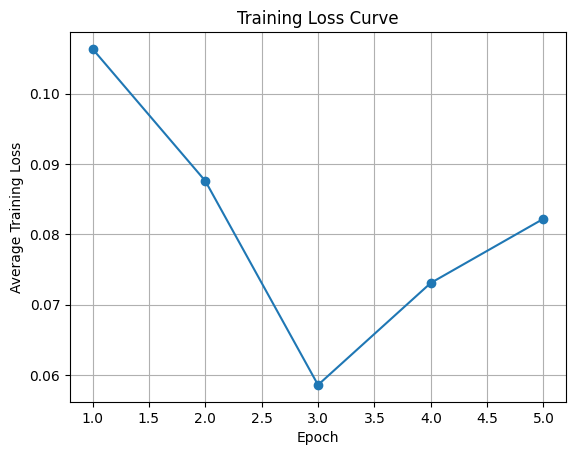

In [86]:
import matplotlib.pyplot as plt

plt.plot(
    range(1, num_epochs + 1),
    training_losses,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Average Training Loss")
plt.title("Training Loss Curve")
plt.grid()
plt.show()

In [87]:
from torchvision import datasets
from torch.utils.data import DataLoader

In [88]:
test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

In [89]:
test_dataset = datasets.ImageFolder(
    root="../data/Testing",
    transform=test_transform
)

In [90]:
test_loader = DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=False
)

In [91]:
print(len(test_dataset))

1600


In [92]:
print(test_dataset.classes)

['glioma', 'meningioma', 'notumor', 'pituitary']


In [93]:
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [94]:
with torch.no_grad():

    print("Testing Mode")

Testing Mode


In [95]:
model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        outputs = model(images)

        print(outputs.shape)

        break

torch.Size([8, 4])


In [96]:
_, predicted = torch.max(outputs,1)

print(predicted)

tensor([1, 0, 0, 0, 2, 2, 1, 0])


In [97]:
print("Prediction:", predicted)

print("Actual:", labels)

Prediction: tensor([1, 0, 0, 0, 2, 2, 1, 0])
Actual: tensor([0, 0, 0, 0, 0, 0, 0, 0])


In [98]:
correct = (predicted == labels)

print(correct)

tensor([False,  True,  True,  True, False, False, False,  True])


In [99]:
print(correct.sum())

tensor(4)


In [100]:
accuracy = correct.sum().item()/len(labels)

print(accuracy)

0.5


# Evaluate Entire Test Dataset

In [101]:
correct = 0
total = 0

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        correct += (predicted == labels).sum().item()

        total += labels.size(0)

accuracy = correct / total

print(f"Correct Predictions : {correct}")
print(f"Total Images : {total}")
print(f"Accuracy : {accuracy:.4f}")

Correct Predictions : 1481
Total Images : 1600
Accuracy : 0.9256


In [102]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [103]:
all_predictions = []

all_labels = []

In [104]:
model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        outputs = model(images)

        _, predicted = torch.max(outputs,1)

        all_predictions.extend(predicted.numpy())

        all_labels.extend(labels.numpy())

In [105]:
cm = confusion_matrix(
    all_labels,
    all_predictions
)

In [106]:
print(cm)

[[309  50  38   3]
 [  8 377   3  12]
 [  0   1 399   0]
 [  3   1   0 396]]


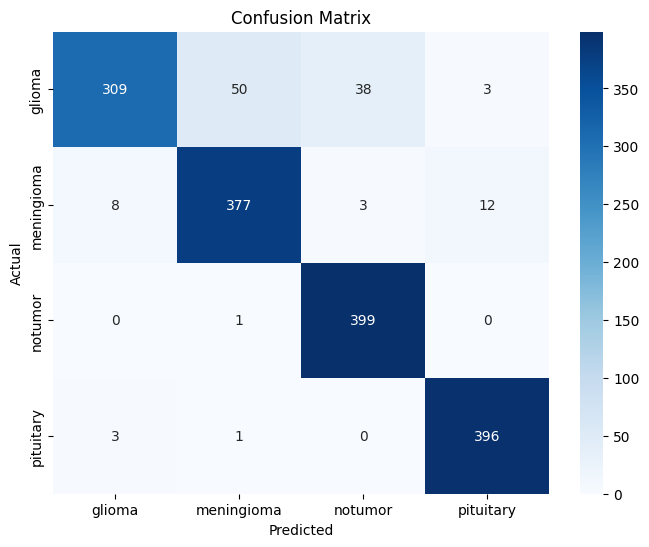

In [107]:
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=test_dataset.classes,
    yticklabels=test_dataset.classes
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [108]:
from sklearn.metrics import precision_score

In [109]:
precision = precision_score(
    all_labels,
    all_predictions,
    average="macro"
)

print(precision)

0.9286836775602743


In [110]:
from sklearn.metrics import recall_score

In [111]:
recall = recall_score(
    all_labels,
    all_predictions,
    average="macro"
)

print(recall)

0.9256249999999999


In [112]:
from sklearn.metrics import f1_score

In [113]:
f1 = f1_score(
    all_labels,
    all_predictions,
    average="macro"
)

print(f1)

0.923608755045348


In [114]:
from sklearn.metrics import roc_curve

In [115]:
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize

In [117]:
all_probs = []
all_labels = []

In [118]:
model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        outputs = model(images)

        probabilities = torch.softmax(outputs, dim=1)

        all_probs.extend(probabilities.numpy())

        all_labels.extend(labels.numpy())

In [119]:
import numpy as np

all_labels = np.array(all_labels)

all_probs = np.array(all_probs)

In [120]:
all_labels_binary = label_binarize(
    all_labels,
    classes=[0,1,2,3]
)

In [121]:
auc = roc_auc_score(

    all_labels_binary,

    all_probs,

    multi_class="ovr",

    average="macro"

)

print("ROC-AUC:", auc)

ROC-AUC: 0.97709765625


In [122]:
torch.save(
    model.state_dict(),
    "../models/resnet18_brain_tumor.pth"
)

print("Model saved successfully!")

Model saved successfully!
